# Privacy Risk Factors

Analysis for permissions, trackers, and their relationships with privacy metrics.

# Common setup and data preparation

In [9]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 200
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 120)

metrics_results = Path("../data/mhealth_apps_metrics.csv")
if not metrics_results.exists():
    raise FileNotFoundError(
        "Could not find `mhealth_apps_metrics.csv` in the notebook folder or at ../data/."
    )

REGION_MAP = {
    "us": "North America", "ca": "North America", "gl":"North America",
    "mx": "Latin America", "br": "Latin America", "ar": "Latin America", 
    "cl": "Latin America",
    "de": "Europe", "fr": "Europe", "gb": "Europe", 
    "pl": "Europe",
    "tr": "Middle East", "il": "Middle East", "sa": "Middle East", 
    "ae": "Middle East",
    "in": "Asia", "jp": "Asia", "sg": "Asia", 
    "kr": "Asia",
    "za": "Africa", "mz": "Africa", "ng": "Africa", 
    "ke": "Africa",
    "au": "Oceania", "nz": "Oceania", 
    "pg": "Oceania"
}

COUNTRY_LABEL_MAP = {
    "us": "United States", "ca": "Canada", "gl":"Greenland",
    "mx": "Mexico", "br": "Brazil", "ar": "Argentina",
    "cl": "Chile",
    "de": "Germany", "fr": "France", "gb": "Great Britain",
    "pl": "Poland",
    "tr": "Turkey", "il": "Israel", "sa": "Saudi Arabia",
    "ae": "United Arab Emirates",
    "in": "India", "jp": "Japan", "sg": "Singapore",
    "kr": "South Korea",
    "za": "South Africa", "mz": "Mozambique", "ng": "Nigeria",
    "ke": "Kenya",
    "au": "Australia", "nz": "New Zealand",
    "pg": "Papua New Guinea"
}

REGION_ORDER = [
    "North America", "Latin America", "Europe",
    "Middle East", "Asia", "Africa", "Oceania"
]

region_palette = plt.cm.tab10(np.linspace(0, 1, len(REGION_ORDER)))
REGION_COLORS = {region: region_palette[i] for i, region in enumerate(REGION_ORDER)}
category_palette = plt.cm.tab20(np.linspace(0, 1, 20))


In [10]:
import pandas as pd

df = pd.read_csv(metrics_results, low_memory=False)
print("Raw shape:", df.shape)

required_metrics = ["ADII", "DGI", "PCLR", "AS"]
missing_required = [c for c in required_metrics if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required metric columns: {missing_required}")

analysis_df = df.copy()

print("Analysis shape:", analysis_df.shape)
print("Unique apps:", analysis_df["app_id"].nunique())

display_cols = [
    "app_id", "country", "country_label", "region", "category",
    "ADII", "DGI", "PCLR", "AS",
    "observed_count", "disclosed_count", "missing_count", "misleading_count"
]
display_cols = [c for c in display_cols if c in analysis_df.columns]

Raw shape: (23392, 134)
Analysis shape: (23392, 134)
Unique apps: 931


In [11]:

summary = pd.DataFrame({
    "non_null": analysis_df[["ADII", "DGI", "PCLR", "AS"]].notna().sum(),
    "mean": analysis_df[["ADII", "DGI", "PCLR", "AS"]].mean(),
    "median": analysis_df[["ADII", "DGI", "PCLR", "AS"]].median(),
    "std": analysis_df[["ADII", "DGI", "PCLR", "AS"]].std(),
    "min": analysis_df[["ADII", "DGI", "PCLR", "AS"]].min(),
    "max": analysis_df[["ADII", "DGI", "PCLR", "AS"]].max(),
}).round(4)
summary


,non_null,mean,median,std,min,max
ADII,23392,189.0859,100.0000,323.8028,7.0000,12935.0000
DGI,23392,0.2559,0.0000,0.3968,0.0000,1.0000
PCLR,11967,0.3063,0.2000,0.3386,0.0000,1.0000
AS,23383,0.3787,0.3761,0.0924,0.1064,0.7473


In [12]:

country_level = analysis_df.copy()

metric_agg = {
    "ADII": "mean",
    "DGI": "mean",
    "PCLR": "mean",
    "AS": "mean",
}

meta_agg = {
    "country_label": "nunique",
    "region": lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan,
    "category": lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan,
    "num_permissions": "mean",
    "num_dangerous_permissions": "mean",
    "num_trackers": "mean",
    "downloads_int": "mean",
    "average_score": "mean",
}

agg_dict = {}
for k, v in {**metric_agg, **meta_agg}.items():
    if k in analysis_df.columns:
        agg_dict[k] = v

app_level = analysis_df.groupby("app_id", as_index=False).agg(agg_dict)
app_level = app_level.rename(columns={"country_label": "country_count"})
app_level_all = app_level.copy()

if "PCLR" not in app_level_all.columns:
    if "app_country_PCLR" in analysis_df.columns:
        pclr_fallback = (
            analysis_df.groupby("app_id", as_index=False)["app_country_PCLR"]
            .mean()
            .rename(columns={"app_country_PCLR": "PCLR"})
        )
        app_level_all = app_level_all.merge(pclr_fallback, on="app_id", how="left")
    elif {"app_country_pre_sensitive_instances", "app_country_total_sensitive_instances"}.issubset(analysis_df.columns):
        pclr_fallback = (
            analysis_df.groupby("app_id", as_index=False)[
                ["app_country_pre_sensitive_instances", "app_country_total_sensitive_instances"]
            ]
            .mean()
        )
        denom = pclr_fallback["app_country_total_sensitive_instances"].replace(0, np.nan)
        pclr_fallback["PCLR"] = pclr_fallback["app_country_pre_sensitive_instances"] / denom
        app_level_all = app_level_all.merge(pclr_fallback[["app_id", "PCLR"]], on="app_id", how="left")

print("Country-level rows:", len(country_level))
print("App-level rows:", len(app_level_all))
print("App-level metric columns:", [c for c in ["ADII", "DGI", "PCLR", "AS"] if c in app_level_all.columns])
app_level = app_level_all.copy()



Country-level rows: 23392
App-level rows: 931
App-level metric columns: ['ADII', 'DGI', 'PCLR', 'AS']



## 1. Figure — Scatter view of invasiveness vs disclosure gap

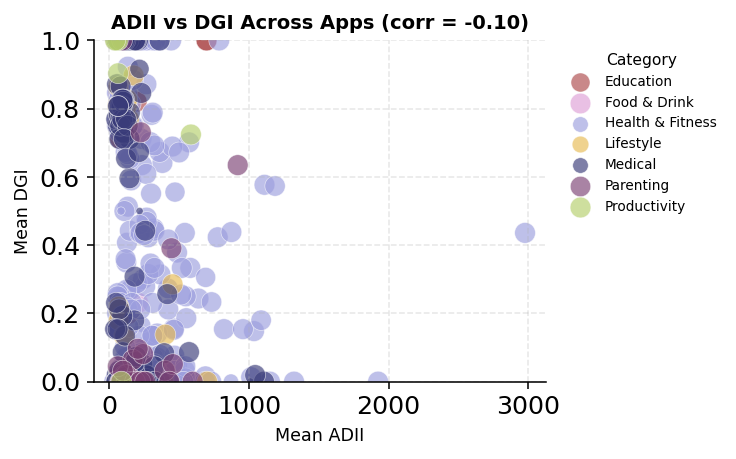

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plot_df = app_level_all.copy() if "app_level_all" in globals() else app_level.copy()

metric_aliases = {
    "ADII": ["ADII", "ADII_mean", "ADII_median"],
    "DGI": ["DGI", "DGI_mean", "DGI_median"],
    "country_count": ["country_count", "n_countries"],
}
for target, candidates in metric_aliases.items():
    if target not in plot_df.columns:
        for cand in candidates:
            if cand in plot_df.columns:
                plot_df[target] = plot_df[cand]
                break

required_cols = ["category", "ADII", "DGI", "country_count"]
missing = [c for c in required_cols if c not in plot_df.columns]
if missing:
    raise KeyError(f"Missing required columns for plotting: {missing}")

plot_df = plot_df.dropna(subset=["category", "ADII", "DGI"]).copy()

top_categories = plot_df["category"].value_counts().head(10).index.tolist()
plot_df["category_simple"] = plot_df["category"].where(
    plot_df["category"].isin(top_categories), "Other"
)

all_plot_categories = plot_df["category_simple"].unique().tolist()
extra_palette = plt.cm.tab20b(np.linspace(0, 1, len(all_plot_categories)))
plot_category_colors = {cat: extra_palette[i] for i, cat in enumerate(all_plot_categories)}

fig, ax = plt.subplots(figsize=(5.5, 3.5))

for cat, sub in plot_df.groupby("category_simple"):
    ax.scatter(
        sub["ADII"],
        sub["DGI"],
        s=10 + 4 * pd.to_numeric(sub["country_count"], errors="coerce").fillna(1).clip(lower=1),
        alpha=0.65,
        label=cat,
        color=plot_category_colors[cat],
        edgecolor="white",
        linewidth=0.35
    )

corr = plot_df[["ADII", "DGI"]].corr().iloc[0, 1]

ax.set_title(
    f"ADII vs DGI Across Apps (corr = {corr:.2f})",
    fontsize=10,
    weight="bold"
)
ax.set_xlabel("Mean ADII", fontsize=9)
ax.set_ylabel("Mean DGI", fontsize=9)
ax.set_ylim(0, 1)
ax.grid(True, linestyle="--", alpha=0.3)

ax.legend(
    title="Category",
    fontsize=7,
    title_fontsize=8,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

plt.tight_layout()
plt.show()

In [14]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

try:
    import statsmodels.api as sm
    HAS_STATSMODELS = True
except Exception:
    HAS_STATSMODELS = False
    print("statsmodels is not available; regression cells will be skipped.")

FIG_DIR = Path("../figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

if "app_level_all" in globals():
    biz_df = app_level_all.copy()
elif "app_level" in globals():
    biz_df = app_level.copy()
elif "analysis_df" in globals():
    biz_df = analysis_df.drop_duplicates(subset=["app_id"]).copy()
else:
    raise NameError("Expected one of app_level_all, app_level, or analysis_df to exist.")

print(f"Initial shape: {biz_df.shape}")

Initial shape: (931, 13)


In [15]:
if "paid_app" not in biz_df.columns:
    if "free" in biz_df.columns:
        biz_df["paid_app"] = (~biz_df["free"].fillna(True)).astype(int)
    elif "price" in biz_df.columns:
        biz_df["paid_app"] = (
            pd.to_numeric(biz_df["price"], errors="coerce")
            .fillna(0)
            .gt(0)
            .astype(int)
        )

if "offersIAP" in biz_df.columns and "has_iap" not in biz_df.columns:
    biz_df["has_iap"] = biz_df["offersIAP"].fillna(False).astype(int)

if "ad_supported" in biz_df.columns and "has_ads" not in biz_df.columns:
    biz_df["has_ads"] = biz_df["ad_supported"].fillna(False).astype(int)

if "downloads_int" in biz_df.columns:
    biz_df["downloads_int"] = pd.to_numeric(biz_df["downloads_int"], errors="coerce")
    biz_df["log_downloads"] = np.log1p(biz_df["downloads_int"])

metric_candidates = {
    "ADII": ["ADII", "ADII_mean"],
    "DGI": ["DGI", "DGI_mean"],
    "PCLR": ["PCLR", "PCLR_mean"],
    "AS": ["AS", "AS_mean"]
}

for target, candidates in metric_candidates.items():
    if target not in biz_df.columns:
        for cand in candidates:
            if cand in biz_df.columns:
                biz_df[target] = biz_df[cand]
                break

numeric_cols = [
    "ADII", "DGI", "PCLR", "AS",
    "num_trackers", "num_permissions", "num_dangerous_permissions",
    "average_score", "log_downloads", "downloads_int"
]
for c in numeric_cols:
    if c in biz_df.columns:
        biz_df[c] = pd.to_numeric(biz_df[c], errors="coerce")

if "top_grossing" in biz_df.columns:
    biz_df["top_grossing_flag"] = (
        biz_df["top_grossing"]
        .astype(str)
        .str.strip()
        .str.lower()
        .isin(["yes", "true", "1"])
        .astype(int)
    )

keep_cols = [c for c in [
    "app_id", "app_name", "category", "categories", "region",
    "has_ads", "has_iap", "paid_app",
    "num_trackers", "num_permissions", "num_dangerous_permissions",
    "downloads_int", "log_downloads", "average_score", "top_grossing_flag",
    "ADII", "DGI", "PCLR", "AS"
] if c in biz_df.columns]

biz_df = biz_df[keep_cols].copy()

print("Prepared shape:", biz_df.shape)

Prepared shape: (931, 13)


combined_privacy_relationships app-level N: 924


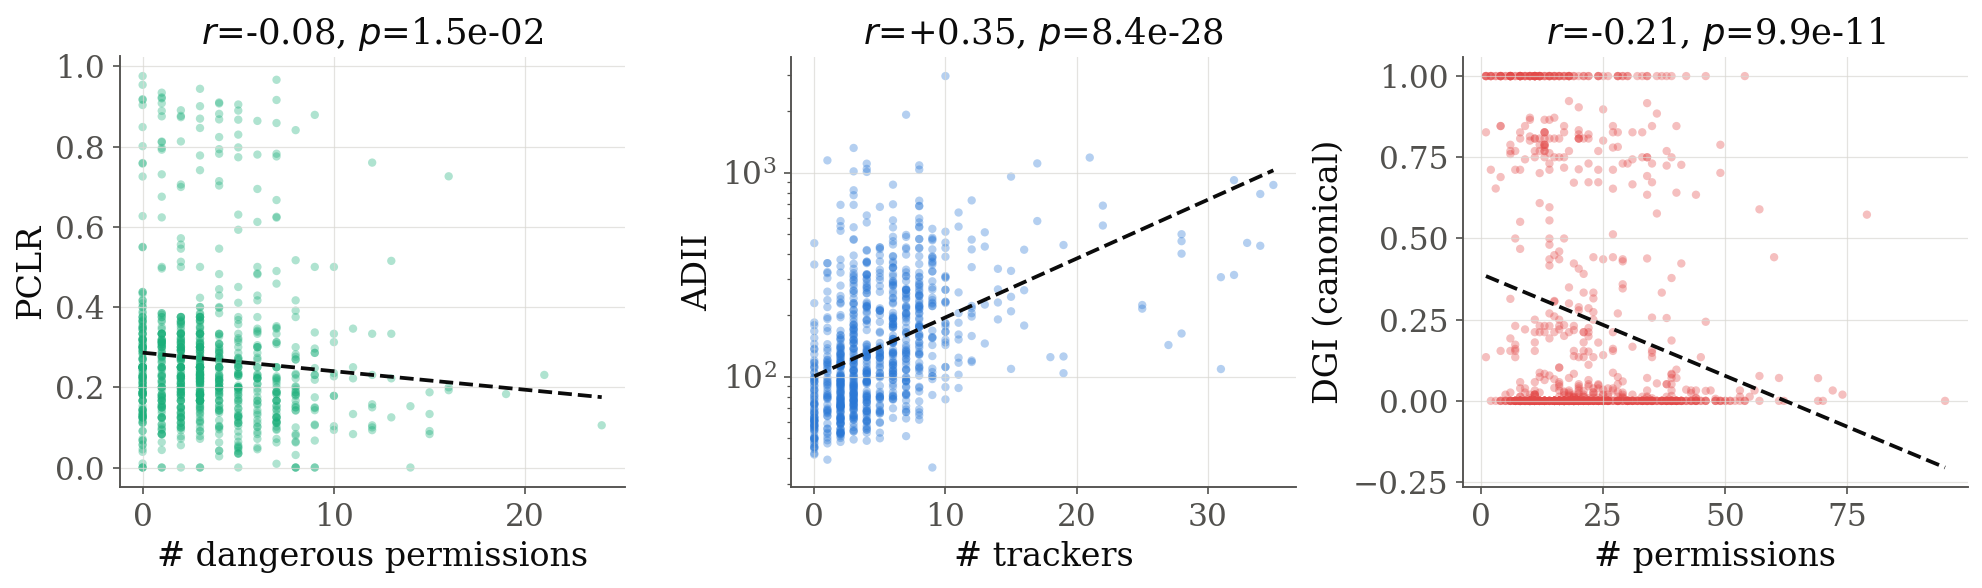

In [16]:
# -------------------------------------------------------------------
# Figure: combined_privacy_relationships (3-panel)
# -------------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from pathlib import Path

FIG_DIR = Path(FIG_DIR) if "FIG_DIR" in globals() else Path("../figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

CATV = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
TEXT_PRIMARY = "#0b0b0b"
TEXT_SECONDARY = "#52514e"
GRID_COLOR = "#d9d8d3"

plt.rcParams.update({
    "font.size": 16,
    "font.family": "serif",
    "axes.titlesize": 17,
    "axes.labelsize": 16,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 14,
    "axes.edgecolor": TEXT_SECONDARY,
    "axes.labelcolor": TEXT_PRIMARY,
    "text.color": TEXT_PRIMARY,
    "xtick.color": TEXT_SECONDARY,
    "ytick.color": TEXT_SECONDARY,
    "axes.grid": True,
    "grid.color": GRID_COLOR,
    "grid.linewidth": 0.6,
    "grid.alpha": 0.7,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.9,
    "lines.linewidth": 1.8,
    "pdf.fonttype": 42,
    "figure.dpi": 150,
})

crel_df = df.groupby("app_id").agg(
    ADII=("ADII", "mean"), PCLR=("PCLR", "mean"),
    num_dangerous_permissions=("num_dangerous_permissions", "first"),
    num_trackers=("num_trackers", "first"), num_permissions=("num_permissions", "first"),
).dropna()

app_dgi_mean = df.groupby("app_id")["DGI"].mean().dropna()
crel_df = crel_df.join(app_dgi_mean.rename("DGI"), how="inner")

print("combined_privacy_relationships app-level N:", len(crel_df))

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))
panels = [
    ("num_dangerous_permissions", "PCLR", "# dangerous permissions", "PCLR", CATV[2], False),
    ("num_trackers", "ADII", "# trackers", "ADII", CATV[0], True),
    ("num_permissions", "DGI", "# permissions", "DGI (canonical)", CATV[7], False),
]
for ax, (xcol, ycol, xlabel, ylabel, color, logy) in zip(axes, panels):
    x, y = crel_df[xcol].values, crel_df[ycol].values
    ax.scatter(x, y, s=16, alpha=0.35, color=color, edgecolors="none")
    r, p = pearsonr(x, y)
    z = np.polyfit(x, np.log(y) if logy else y, 1)
    xs = np.linspace(x.min(), x.max(), 50)
    fit = np.exp(np.polyval(z, xs)) if logy else np.polyval(z, xs)
    ax.plot(xs, fit, color=TEXT_PRIMARY, linestyle="--", linewidth=1.8)
    if logy:
        ax.set_yscale("log")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(f"$r$={r:+.2f}, $p$={p:.1e}")
fig.tight_layout()
fig.savefig(FIG_DIR / "combined_privacy_relationships.pdf", format="pdf", bbox_inches="tight")
plt.show()
